We can motivate the kernel regression model from a different perspective, starting with kernel density estimation. Suppose we have a training set $\{\mathbf{x}_n, t_n\}$ and we use a Parzen density estimator to model the joint distribution $p(\mathbf{x}, t)$, so that
$$ p(\mathbf{x}, t) = \frac{1}{N} \sum_{n=1}^N f(\mathbf{x} - \mathbf{x}_n, t- t_n) $$
where $f(\mathbf{X}, t)$ is the component density function, and there is one such component centred on each data point. The conditional average of the target variable conditioned on the input variable is given by
$$ y(\mathbf{x}) = \mathbb{E}[t\mid \mathbf{x}] = \int_\mathbb{R} t p(t\mid\mathbf{x})\, dt = \frac{\int_\mathbb{R} t p(\mathbf{x},t)\,dt}{\int_\mathbb{R}p(\mathbf{x},t)\,dt} = \frac{\sum_{n=1}^N \int_\mathbb{R}t  f(\mathbf{x} - \mathbf{x}_n, t- t_n)\, dt}{\sum_{m=1}^N\int_\mathbb{R} t f(\mathbf{x} - \mathbf{x}_m, t- t_m)\, dt} $$
Assuming that each component has zero mean, we get $\int_\mathbb{R} t f(\mathbf{x},t)\, dt = 0$, and a change of variables yields
$$ y(\mathbf{x}) = \frac{\sum_{n=1}^N g(\mathbf{x}-\mathbf{x}_n) t_n}{\sum_{m=1}^N g(\mathbf{x}-\mathbf{x}_m)} = \sum_{n=1}^N \frac{g(\mathbf{x}-\mathbf{x}_n)}{\sum_{m=1}^N g(\mathbf{x}-\mathbf{x}_m)}t_n = \sum_{n=1}^N k(\mathbf{x},\mathbf{x}_n) t_n$$
where $k(\cdot,\cdot)$ is a proper kernel since $g(\mathbf{x}) = \int_\mathbb{R} f(\mathbf{x},t)\,dt$. This result is known as the Nadaraya-Watson model, or kernel regression.

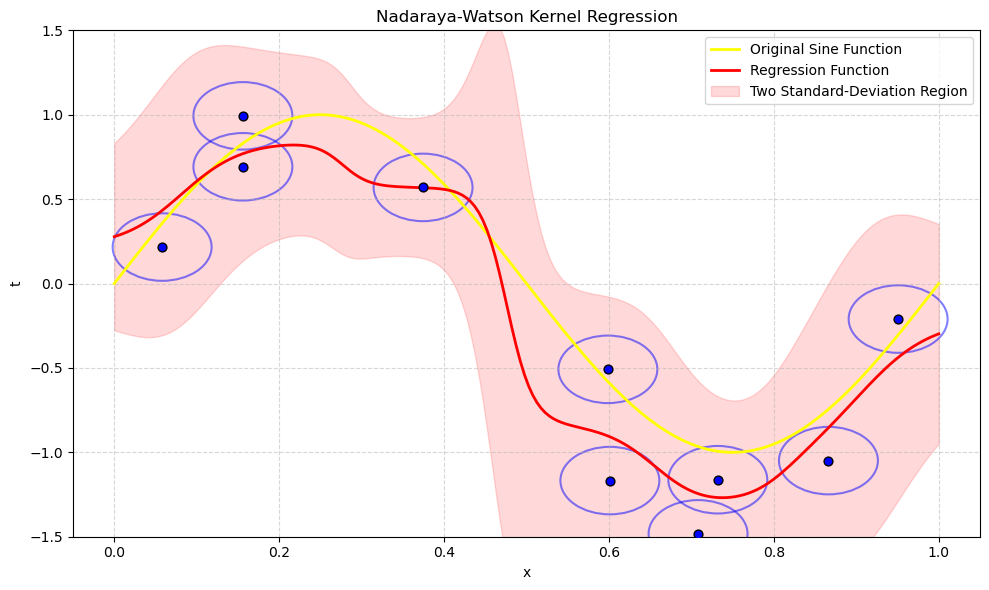

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Setup Data Generation
np.random.seed(42)
N = 10
x_data = np.sort(np.random.uniform(0, 1, N))
y_true = np.sin(2 * np.pi * x_data)
t_data = y_true + np.random.normal(0, 0.3, N)

x_grid = np.linspace(0, 1, 200)
y_grid_true = np.sin(2 * np.pi * x_grid)

# Nadaraya-Watson Kernel Regression Model
h = 0.06 # Isotropic Gaussian kernel with width h

def gaussian_kernel(x1, x2, bandwidth):
    return np.exp(-((x1 - x2) ** 2) / (2 * bandwidth ** 2))

# Compute the conditional mean (red line) and variance (red shading)
conditional_mean = []
conditional_var = []
noise_variance = 0.04  # Ambient noise variance parameter sigma^2

for x in x_grid:
    # Compute kernel weights between current x and all training data points
    kernels = gaussian_kernel(x, x_data, h)
    weights = kernels / np.sum(kernels)
    
    # Conditional Mean
    mean_val = np.sum(weights * t_data)
    conditional_mean.append(mean_val)
    
    # Conditional Variance: includes both kernel interpolation uncertainty and data noise
    var_val = noise_variance + np.sum(weights * (t_data - mean_val)**2)
    conditional_var.append(var_val)

conditional_mean = np.array(conditional_mean)
std_dev = np.sqrt(np.array(conditional_var))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot true function (yellow line)
ax.plot(x_grid, y_grid_true, color='yellow', linewidth=2, label='Original Sine Function')

# Plot Regression function (red) and its 2x Standard Deviation (shaded region)
ax.plot(x_grid, conditional_mean, color='red', linewidth=2, label='Regression Function')
ax.fill_between(x_grid, conditional_mean - 2 * std_dev, conditional_mean + 2 * std_dev,
                color='red', alpha=0.15, label='Two Standard-Deviation Region')

ax.scatter(x_data, t_data, color='blue', edgecolor='k', zorder=5, s=40)

# Because the axis scaling differs, standard isotropic circles appear elliptical
for xi, ti in zip(x_data, t_data):
    ellipse = Ellipse((xi, ti), width=2*h, height=2*np.sqrt(noise_variance), 
                      edgecolor='blue', facecolor='none', alpha=0.5, linestyle='-', linewidth=1.5)
    ax.add_patch(ellipse)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Nadaraya-Watson Kernel Regression')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

A key point about Gaussian stochastic processes is that the joint distribution over N variables $y_1, \dots, y_N$ is specified completely by the second-order statistics, namely the mean and the covariance. However, in many case the mean is set to zero (as there is no information, and then we can expoit the symmetric property), then the specification is left to the covariance of $y(\mathbf{x})$, evaluated at any two values of x, which is given by the kernel function $\mathbb{E}[y(\mathbf{x}_n)y(\mathbf{x}_m)] = k(\mathbf{x}_n, \mathbf{x}_m)$.

For the specific case of a Gaussian process defined by the linear regression model with a weight prior, the kernel function is given by
$$ k(\mathbf{x}_n, \mathbf{x}_m) = \frac{1}{\alpha} \phi(\mathbf{x}_n)^\top \phi(\mathbf{x}_m) $$
We can also define the kernel function directly, rather than indirectly through a choice of basis function, and a classical example here is given by the Exponential kernel, corresponding to the Ornstein-Uhlenbeck process,
$$ k(\mathbf{x}_n, \mathbf{x}_m) = \exp(-\theta \Vert \mathbf{x}_n - \mathbf{x}_m \Vert) $$

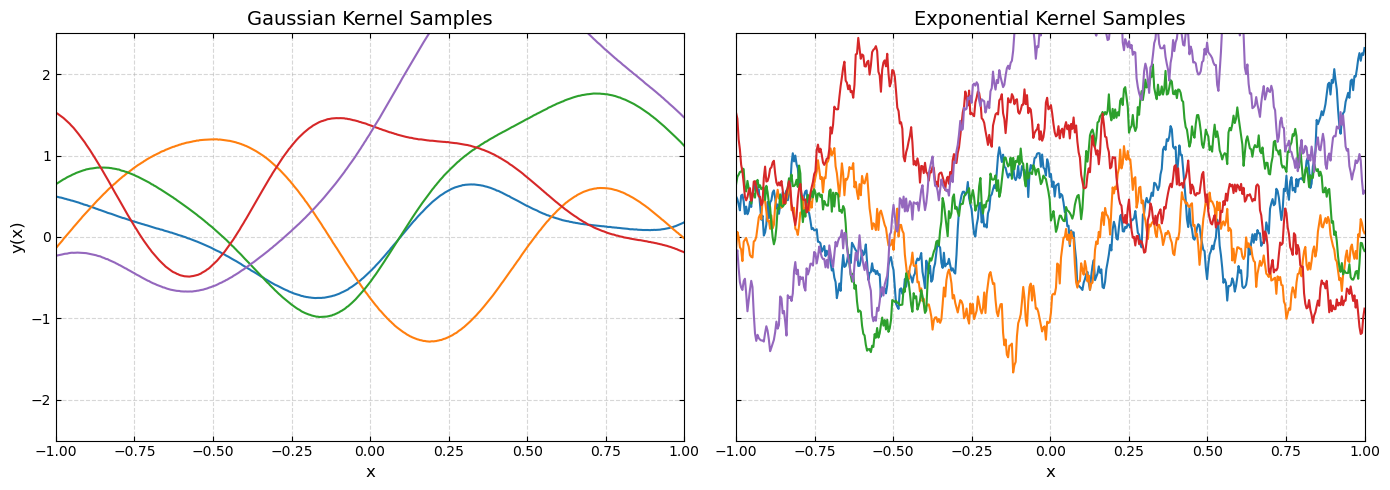

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Input Space and Dimensions
np.random.seed(42)
x = np.linspace(-1, 1, 500)
N_samples = 5  # Number of random sample paths to draw
theta = 5.0    # Kernel scale parameter

def gaussian_kernel(x1, x2, theta):
    X1, X2 = np.meshgrid(x1, x2)
    return np.exp(-theta * (X1 - X2)**2)
def exponential_kernel(x1, x2, theta):
    X1, X2 = np.meshgrid(x1, x2)
    return np.exp(-theta * np.abs(X1 - X2))

# Small ridge (1e-6) added to the diagonal to ensure numerical stability
K_gauss = gaussian_kernel(x, x, theta=5.0) + 1e-6 * np.eye(len(x))
K_exp = exponential_kernel(x, x, theta=2.0) + 1e-6 * np.eye(len(x))

# Draw Random Samples via Multivariate Normal (using Cholesky decomposition)
L_gauss = np.linalg.cholesky(K_gauss)
L_exp = np.linalg.cholesky(K_exp)

z = np.random.normal(0, 1, size=(len(x), N_samples))
samples_gauss = np.dot(L_gauss, z)
samples_exp = np.dot(L_exp, z)

# Plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: Gaussian Kernel
axs[0].plot(x, samples_gauss)
axs[0].set_title("Gaussian Kernel Samples", fontsize=14)
axs[0].set_xlabel("x", fontsize=12)
axs[0].set_ylabel("y(x)", fontsize=12)

# Right: Exponential Kernel
axs[1].plot(x, samples_exp)
axs[1].set_title("Exponential Kernel Samples", fontsize=14)
axs[1].set_xlabel("x", fontsize=12)

for ax in axs:
    ax.set_xlim(-1, 1)
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()

In order to apply Gaussian process models to the problem of regression, we need to take account of the noise on the observed target values, i.e. $t_n = y(\mathbf{x}_n) + \varepsilon_n$, so that $p(t_n\mid y(\mathbf{x}_n) ) = \mathcal{N}(t_n \mid y(\mathbf{x}_n),\beta^{-1})$. From the Gaussian Process' definition, we have $p(\mathbf{y}) = \mathcal{N}(\mathbf{y}\mid \mathbf{0},\mathbf{K})$, where the kernel function that determines $\mathbf{K}$ is typically chose to express the property that, for similar $\mathbf{x}_n$ and $\mathbf{x}_m$, the quantities $y(\mathbf{x}_n)$ and $y(\mathbf{x}_m)$ will be more strongly connected than dissimilar points. The marginal distribution for $\mathbf{t}$ is resorted by using classical properties of the Gaussian distribution (can be found at eq. 2.115),
$$ p(\mathbf{t}) = \int_{\mathbb{R}^n} p(\mathbf{t} \mid \mathbf{y}) p(\mathbf{y})\, d\mathbf{y} = \int_{\mathbb{R}^n} \mathcal{N}(\mathbf{t} \mid \mathbf{y}, \beta^{-1}\mathbf{I}) \mathcal{N}(\mathbf{y} \mid \mathbf{0}, \mathbf{K})\, d\mathbf{y} =  \mathcal{N}(\mathbf{t} \mid \mathbf{I}\cdot\mathbf{0}, \beta^{-1}\mathbf{I} + \mathbf{I}\mathbf{K}\mathbf{I}^\top) = \mathcal{N}(\mathbf{t} \mid \mathbf{0}, \beta^{-1}\mathbf{I}+ \mathbf{K}) $$
such that $C(\mathbf{x}_n,\mathbf{x}_m) = k(\mathbf{x}_n,\mathbf{x}_m) + \beta^{-1}\delta_{nm} $. Clearly,
$$ p(\mathbf{t}_{N+1}) = \mathcal{N}(\mathbf{t}_{N+1}\mid \mathbf{0}, \mathbf{C}_{N+1}) = \mathcal{N}\left ( \begin{pmatrix} \mathbf{0} \\ 0 \end{pmatrix}, \begin{pmatrix} \mathbf{C}_N & \mathbf{k}\\ \mathbf{k}^\top & c \end{pmatrix} \right ) $$
where $\mathbf{k}$ has elements $k(\mathbf{x}_n, \mathbf{x}_{N+1})$ for $n = 1,\dots,N$ and $c = k(\mathbf{x}_{N+1},\mathbf{x}_{N+1}) + \beta^{-1}$. Then, using some classical properties of conditioning Gaussian distributions (can be found at eq. 2.81 and 2.82), $p(t_{N+1}\mid \mathbf{t}) = \mathcal{N}(t_{N+1}\mid m(\mathbf{x}_{N+1}), \sigma^2(\mathbf{x}_{N+1}))$, where
$$ m(\mathbf{x}_{N+1}) = 0 + \mathbf{k}^\top \mathbf{C}_N^{-1}(\mathbf{t}-\mathbf{0}) = \mathbf{k}^\top \mathbf{C}_N^{-1}\mathbf{t}, \quad \sigma^2(\mathbf{x}_{N+1}) = c-\mathbf{k}^\top \mathbf{C}_N^{-1} \mathbf{k} $$

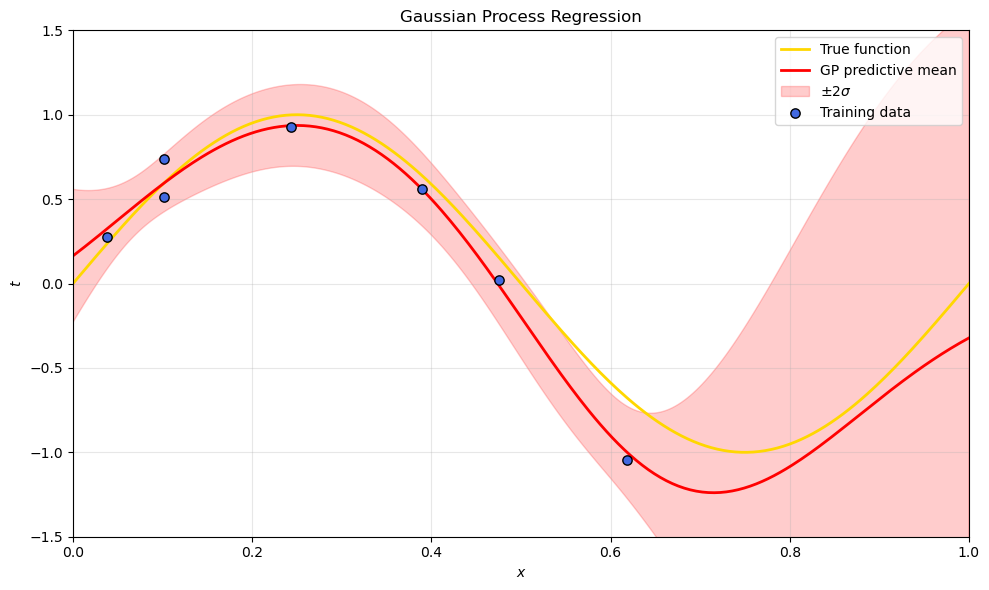

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility and generate data
np.random.seed(42)
N = 7
noise_variance = 0.02

x_train = np.sort(np.random.uniform(0, 0.65, N))
t_train = np.sin(2 * np.pi * x_train) + np.random.normal(0, np.sqrt(noise_variance), N)

x_test = np.linspace(0, 1, 300)
y_true = np.sin(2 * np.pi * x_test)

# Squared Exponential Kernel
theta0 = 1.0          # signal variance
theta1 = 25.0         # inverse length-scale

def kernel(x1, x2):
    x1 = np.atleast_2d(x1).T
    x2 = np.atleast_2d(x2)
    return theta0 * np.exp(-0.5 * theta1 * (x1 - x2) ** 2)


# Covariance matrices
K = kernel(x_train, x_train)
K += noise_variance * np.eye(N)

K_s = kernel(x_train, x_test)
K_ss = kernel(x_test, x_test)

# GP Posterior
alpha = np.linalg.solve(K, t_train)
mean = K_s.T @ alpha                # Predictive mean
v = np.linalg.solve(K, K_s)         # Predictive covariance
cov = K_ss - K_s.T @ v
variance = np.maximum(np.diag(cov), 0)      # For numerical stability
std = np.sqrt(variance)

# Plot
plt.figure(figsize=(10,6))

plt.plot(x_test, y_true, color='gold', lw=2, label='True function')
plt.plot(x_test, mean, color='red', lw=2, label='GP predictive mean')

plt.fill_between(x_test, mean - 2*std, mean + 2*std, color='red', alpha=0.2, label=r'$\pm2\sigma$')

plt.scatter(x_train, t_train, color='royalblue', edgecolor='k',
            s=45, zorder=5, label='Training data')

plt.xlim(0,1)
plt.ylim(-1.5,1.5)

plt.xlabel("$x$")
plt.ylabel("$t$")
plt.title("Gaussian Process Regression")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

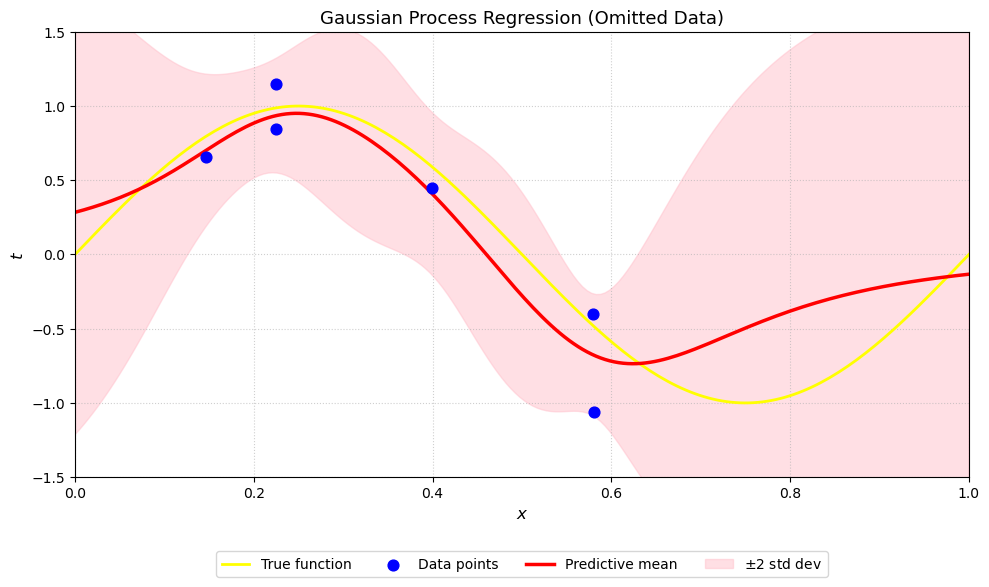

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# set seed for reproducibility
np.random.seed(42)

# True function
def true_func(x):
    return np.sin(2 * np.pi * x)

# Generate data, then omit the the last 3
X_all = np.random.uniform(0.1, 0.9, 10)
X_all.sort()
X_train = X_all[:6].reshape(-1, 1)
noise_std = 0.3
y_train = true_func(X_train) + np.random.normal(0, noise_std, size=X_train.shape)

X_test = np.linspace(0, 1, 200).reshape(-1, 1)


def rational_quadratic_kernel(X1, X2, sigma_f=1.0, l=0.15, alpha=1.0):
    # Pairwise squared Euclidean distances
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return (sigma_f**2) * (1 + sqdist / (2 * alpha * l**2))**(-alpha)

# Gaussian Process Predictive Distribution
K = rational_quadratic_kernel(X_train, X_train) + (noise_std**2) * np.eye(len(X_train))
K_s = rational_quadratic_kernel(X_train, X_test)
K_ss = rational_quadratic_kernel(X_test, X_test) + 1e-8 * np.eye(len(X_test))

K_inv = np.linalg.inv(K)

# Compute predictive mean
mu_s = np.dot(K_s.T, np.dot(K_inv, y_train)).flatten()
# Compute predictive covariance
cov_s = K_ss - np.dot(K_s.T, np.dot(K_inv, K_s))
std_s = np.sqrt(np.diag(cov_s))

# Plot
plt.figure(figsize=(10, 6))

plt.plot(X_test, true_func(X_test), color='yellow', lw=2, label='True function')        # yellow true functoin
plt.scatter(X_train, y_train, color='blue', s=60, zorder=5, label='Data points')        # blue "censored" data
plt.plot(X_test, mu_s, color='red', lw=2.5, label='Predictive mean')                    # red predictive mean

# Shaded region: \pm two std dev (\approx 95\% confidence)
plt.fill_between(X_test.flatten(), 
                 mu_s - 2 * std_s, 
                 mu_s + 2 * std_s, 
                 color='pink', alpha=0.5, label=r'$\pm 2$ std dev')

plt.xlim(0, 1)
plt.ylim(-1.5, 1.5)
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$t$', fontsize=12)
plt.title('Gaussian Process Regression (Omitted Data)', fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

plt.tight_layout()
plt.show()

The optimization of these parameters by Maximum Likelihood allows the relative importance of different inputs to be inferred from the data. This represents an example in the Gaussian process context of automatic relevance determination, or ARD, which was originally formulated in the framework of neural networks. Consider a Gaussian process with a two-dimensional input space $\mathbf{x} = (x_1, x_2)$, having a kernel function of the form
$$ k(\mathbf{x}, \mathbf{x}') = \theta_0 \exp\left\{ - \frac{1}{2} \sum_{i=1}^2 \eta_i(x_i - x'_i)^2 \right\} $$
Now we present samples from the resulting prior over functions $y(\mathbf{x})$ for two different settings of the precision parameters $\eta_i$. As a particular parameter $\eta_i$ becomes small, the function becomes relatively insensitive to the corresponding input variable $x_i$. By adapting these parameters to a data set using Maximum Likelihood, it becomes possible to detect input variables that have little effect on the predictive distribution, because the corresponding values of $\eta_i$ will be small. 

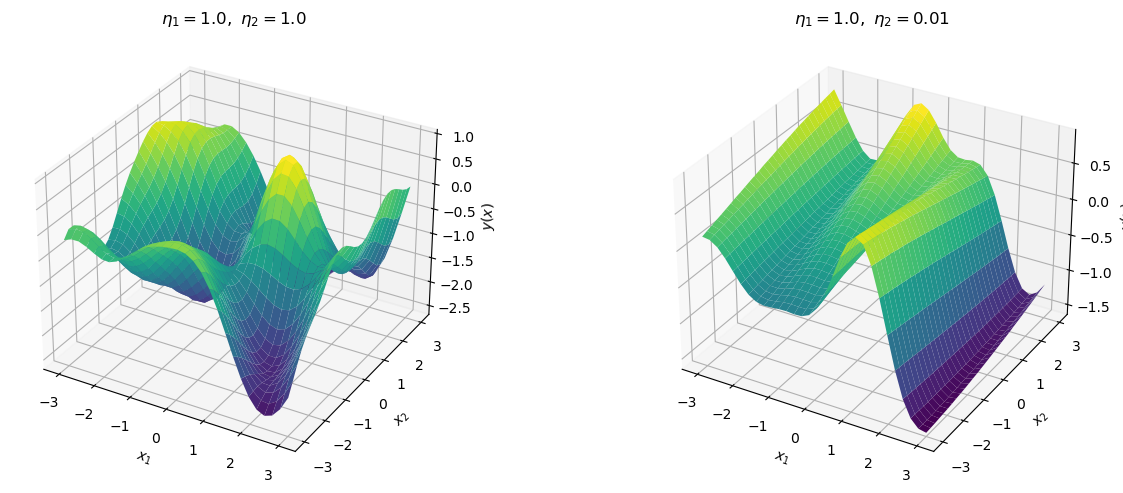

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# ARD kernel
def ard_kernel(X1, X2, theta0=1.0, eta=(1.0, 1.0)):
    eta = np.asarray(eta)

    diff = X1[:, None, :] - X2[None, :, :]
    sqdist = np.sum(eta * diff**2, axis=-1)

    return theta0 * np.exp(-0.5 * sqdist)

# Grid in x1,x2
n = 30
x1 = np.linspace(-3, 3, n)
x2 = np.linspace(-3, 3, n)

X1g, X2g = np.meshgrid(x1, x2)
X = np.column_stack([X1g.ravel(), X2g.ravel()])

# Two ARD settings
etas = [(1.0, 1.0), (1.0, 0.01)]

fig = plt.figure(figsize=(14, 5))

for i, eta in enumerate(etas, start=1):

    K = ard_kernel(X, X, theta0=1.0, eta=eta)

    # numerical stability
    K += 1e-6 * np.eye(len(X))

    # sample from GP prior
    y = np.random.multivariate_normal(
        mean=np.zeros(len(X)),
        cov=K
    )

    Y = y.reshape(n, n)

    ax = fig.add_subplot(1, 2, i, projection='3d')
    ax.plot_surface(X1g, X2g, Y,
                    cmap='viridis',
                    linewidth=0)

    ax.set_title(
        rf'$\eta_1={eta[0]},\ \eta_2={eta[1]}$'
    )
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$y(x)$')

plt.tight_layout()
plt.show()